# **Purpose**

Evaluates the **TinyLlama-1.1B-Chat** (Track C, LLM prompting) distractor predictions
produced by the matching generation notebook — separately for each of the 3
prompting strategies (zero-shot, few-shot, misconception-CoT) — using the
**identical metric suite** as Track A/B: BLEU, ROUGE-1/2/L, METEOR, GPT-2
perplexity, Distinct-1/2, and distractor-vs-answer semantic similarity.

There's no model to load here — this notebook just reads
`llm_tinyllama_predictions.json` (written by the generation notebook) and scores it.

**If you're running this in a separate Kaggle session from the generation
notebook:** `/kaggle/working` is per-session, so this notebook won't see that
notebook's output automatically. Either run both notebooks in the same
session, or add the generation notebook's output as an **Input** to this one
(Add Input → Your Work → Notebook Output Files) — the cell below searches
both locations automatically.

## **Install dependencies**

In [1]:
!pip install -qU \
 evaluate \
 rouge_score \
 sacrebleu \
 nltk \
 sentence-transformers \
 matplotlib \
 torch \
 torchvision \
 torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.8/739.8 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423

## **Load the API Keys and Tokens**

In [2]:
from kaggle_secrets import UserSecretsClient
import os

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")   # must match the exact secret name you set in Kaggle Secrets

os.environ["HF_TOKEN"] = hf_token

In [3]:
import os
os.environ["NLTK_ALLOW_PROXIED_URLOPEN"] = "1"   # Kaggle's network proxy blocks NLTK's default fetch otherwise

import nltk

NLTK_DATA_DIR = "/kaggle/working/nltk_data"
os.makedirs(NLTK_DATA_DIR, exist_ok=True)
if NLTK_DATA_DIR not in nltk.data.path:
    nltk.data.path.insert(0, NLTK_DATA_DIR)

def ensure_nltk_resource(resource_path, download_name, max_attempts=3):
    for attempt in range(1, max_attempts + 1):
        try:
            nltk.data.find(resource_path)
            return True
        except LookupError:
            pass
        try:
            nltk.download(download_name, download_dir=NLTK_DATA_DIR, quiet=True, force=True)
        except Exception as e:
            print(f"[{download_name}] download attempt {attempt} raised: {e}")
    try:
        nltk.data.find(resource_path)
        return True
    except LookupError:
        return False

RESOURCES = [('corpora/wordnet', 'wordnet'), ('corpora/omw-1.4', 'omw-1.4')]

missing = []
for resource_path, download_name in RESOURCES:
    ok = ensure_nltk_resource(resource_path, download_name)
    print(f"{download_name}: {'OK' if ok else 'STILL MISSING'}")
    if not ok:
        missing.append(download_name)

if missing:
    print(f"\nNote: {missing} still not confirmed locally — evaluate.load('meteor') "
          f"usually resolves this itself on first use, so this is not necessarily fatal.")
else:
    print("\nAll required NLTK resources are available.")

wordnet: STILL MISSING
omw-1.4: STILL MISSING

Note: ['wordnet', 'omw-1.4'] still not confirmed locally — evaluate.load('meteor') usually resolves this itself on first use, so this is not necessarily fatal.


## **Imports**

In [4]:
import json
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from sentence_transformers import SentenceTransformer, util as st_util
import evaluate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## **Config**

In [5]:
METHOD_NAME = "tinyllama_llm"
PREDICTIONS_FILENAME = "llm_tinyllama_predictions.json"   # written by the matching generation notebook
OUTPUT_JSON = "/kaggle/working/eval_results_llm_tinyllama.json"

## **Load predictions produced by the generation notebook**

Searches this notebook's own `/kaggle/working` first (same-session run),
then falls back to anything found under `/kaggle/input/` (in case the
generation notebook's output was attached as an Input dataset instead).

In [6]:
candidate_paths = [f"/kaggle/working/{PREDICTIONS_FILENAME}"] + sorted(
    glob.glob(f"/kaggle/input/**/{PREDICTIONS_FILENAME}", recursive=True)
)

PREDICTIONS_JSON = next((p for p in candidate_paths if os.path.exists(p)), None)

if PREDICTIONS_JSON is None:
    raise FileNotFoundError(
        f"Could not find {PREDICTIONS_FILENAME}.\n"
        f"This file is written by the matching generation notebook. Either:\n"
        f"  1) Run the generation notebook in THIS SAME Kaggle session before this cell, or\n"
        f"  2) Add the generation notebook's output as an Input to this notebook "
        f"(Add Input > Your Work > Notebook Output Files), then re-run this cell.\n"
        f"Searched: {candidate_paths}"
    )

print(f"Using predictions file: {PREDICTIONS_JSON}")

with open(PREDICTIONS_JSON) as f:
    data = json.load(f)

records = data["records"]
strategies = data.get("strategies", sorted(set(r["strategy"] for r in records)))

print(f"Loaded {len(records)} records across strategies: {strategies}")
print(f"Model: {data.get('model_name')} | llm_eval_size: {data.get('llm_eval_size')}")

Using predictions file: /kaggle/input/notebooks/gauravdey777/40-generate-tinyllama-llm-race-distractor/llm_tinyllama_predictions.json
Loaded 900 records across strategies: ['zero_shot', 'few_shot', 'misconception_cot']
Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0 | llm_eval_size: 300


## **Metric functions**

Defined once, then applied per-strategy below so every strategy is scored
identically.

In [7]:
bleu = evaluate.load("sacrebleu")
rouge = evaluate.load("rouge")
meteor = evaluate.load("meteor")

gpt2_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
gpt2_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
gpt2_model.eval()

embedder = SentenceTransformer("all-MiniLM-L6-v2")


def distinct_n(preds, n):
    all_ngrams = []
    for pred in preds:
        tokens = pred.split()
        ngrams = list(zip(*[tokens[i:] for i in range(n)]))
        all_ngrams.extend(ngrams)
    if not all_ngrams:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams)


def gpt2_perplexity(preds):
    perplexities = []
    with torch.no_grad():
        for text in preds:
            if not text.strip():
                continue
            encodings = gpt2_tokenizer(text, return_tensors="pt").to(device)
            input_ids = encodings["input_ids"]
            if input_ids.shape[1] < 2:
                continue
            outputs = gpt2_model(input_ids, labels=input_ids)
            perplexities.append(torch.exp(outputs.loss).item())
    return float(np.mean(perplexities)) if perplexities else float("nan")


def score_strategy(strategy_records, strategy_name):
    predictions = [r["generated_distractor"] for r in strategy_records]
    references = [r["gold_distractor"] for r in strategy_records]
    correct_answers = [r["correct_answer"] for r in strategy_records]

    safe_predictions = [p if p.strip() else "[no candidate found]" for p in predictions]

    bleu_score = bleu.compute(
        predictions=safe_predictions, references=[[r] for r in references]
    )["score"]
    rouge_scores = rouge.compute(predictions=safe_predictions, references=references)
    meteor_score = meteor.compute(predictions=safe_predictions, references=references)["meteor"]

    distinct_1 = distinct_n(safe_predictions, 1)
    distinct_2 = distinct_n(safe_predictions, 2)
    perplexity = gpt2_perplexity(safe_predictions)

    pred_emb = embedder.encode(safe_predictions, convert_to_tensor=True, show_progress_bar=False)
    answer_emb = embedder.encode(correct_answers, convert_to_tensor=True, show_progress_bar=False)
    similarities = st_util.cos_sim(pred_emb, answer_emb).diagonal().cpu().numpy()

    mean_similarity = float(similarities.mean())
    pct_high_risk = float((similarities > 0.9).mean() * 100)

    plt.figure(figsize=(6, 4))
    plt.hist(similarities, bins=30)
    plt.axvline(0.9, color="red", linestyle="--", label="high-risk threshold (0.9)")
    plt.xlabel("Cosine similarity (generated distractor, correct answer)")
    plt.ylabel("Count")
    plt.title(f"Distractor-Answer Semantic Similarity \u2014 {METHOD_NAME} / {strategy_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/similarity_distribution_{METHOD_NAME}_{strategy_name}.png", dpi=150)
    plt.show()

    return {
        "strategy": strategy_name,
        "n_items": len(strategy_records),
        "bleu": bleu_score,
        "rouge1": rouge_scores["rouge1"],
        "rouge2": rouge_scores["rouge2"],
        "rougeL": rouge_scores["rougeL"],
        "meteor": meteor_score,
        "gpt2_perplexity": perplexity,
        "distinct_1": distinct_1,
        "distinct_2": distinct_2,
        "mean_answer_similarity": mean_similarity,
        "pct_high_risk_similarity": pct_high_risk,
    }

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## **Score each strategy**


=== Scoring strategy: zero_shot ===


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


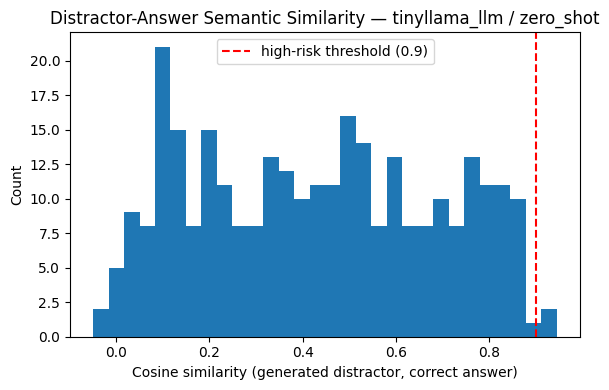

  strategy            : zero_shot
  n_items             : 300
  bleu                : 1.3518
  rouge1              : 0.1117
  rouge2              : 0.0372
  rougeL              : 0.1019
  meteor              : 0.1452
  gpt2_perplexity     : 121.1428
  distinct_1          : 0.3220
  distinct_2          : 0.7103
  mean_answer_similarity: 0.4297
  pct_high_risk_similarity: 0.6667

=== Scoring strategy: few_shot ===


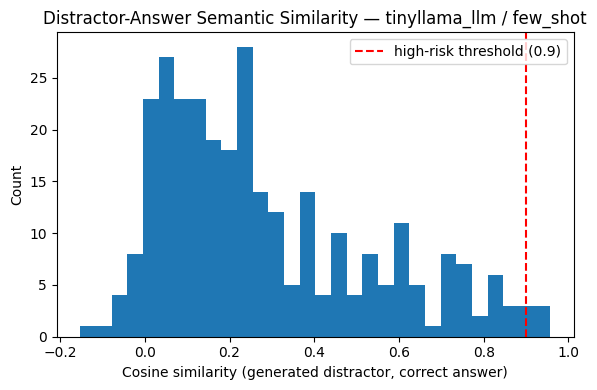

  strategy            : few_shot
  n_items             : 300
  bleu                : 0.9903
  rouge1              : 0.0723
  rouge2              : 0.0167
  rougeL              : 0.0656
  meteor              : 0.0870
  gpt2_perplexity     : 660.6364
  distinct_1          : 0.3574
  distinct_2          : 0.7057
  mean_answer_similarity: 0.2843
  pct_high_risk_similarity: 1.0000

=== Scoring strategy: misconception_cot ===


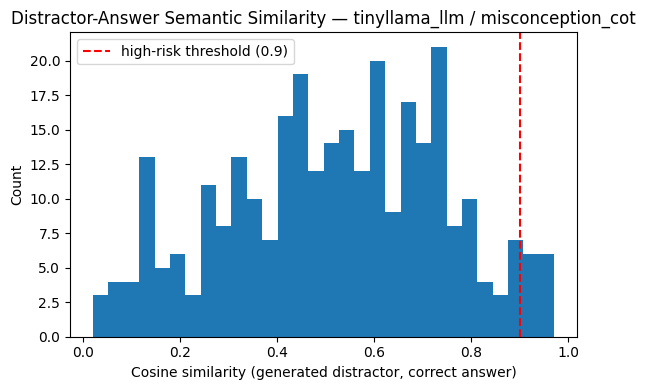

  strategy            : misconception_cot
  n_items             : 300
  bleu                : 0.8782
  rouge1              : 0.1116
  rouge2              : 0.0283
  rougeL              : 0.1013
  meteor              : 0.1485
  gpt2_perplexity     : 118.2435
  distinct_1          : 0.2362
  distinct_2          : 0.5357
  mean_answer_similarity: 0.5198
  pct_high_risk_similarity: 4.6667


In [8]:
per_strategy_results = {}
for strategy in strategies:
    print(f"\n=== Scoring strategy: {strategy} ===")
    strategy_records = [r for r in records if r["strategy"] == strategy]
    result = score_strategy(strategy_records, strategy)
    per_strategy_results[strategy] = result
    for k, v in result.items():
        if isinstance(v, float):
            print(f"  {k:20s}: {v:.4f}")
        else:
            print(f"  {k:20s}: {v}")

## **Assemble and save results**

In [9]:
results = {
    "method": METHOD_NAME,
    "model_name": data.get("model_name"),
    "test_size": data.get("test_size"),
    "seed": data.get("seed"),
    "llm_eval_size": data.get("llm_eval_size"),
    "per_strategy": per_strategy_results,
}

with open(OUTPUT_JSON, "w") as f:
    json.dump(
        {
            "results": results,
            "sample_predictions": {
                strategy: [
                    {
                        "correct_answer": r["correct_answer"],
                        "gold_distractor": r["gold_distractor"],
                        "generated_distractor": r["generated_distractor"],
                    }
                    for r in records if r["strategy"] == strategy
                ][:5]
                for strategy in strategies
            },
        },
        f,
        indent=2,
    )

print(f"Saved results + sample predictions to {OUTPUT_JSON}")

Saved results + sample predictions to /kaggle/working/eval_results_llm_tinyllama.json


## **Compare strategies side by side**

In [10]:
import pandas as pd

comparison_df = pd.DataFrame(per_strategy_results).T
comparison_df

,strategy,n_items,bleu,rouge1,rouge2,rougeL,meteor,gpt2_perplexity,distinct_1,distinct_2,mean_answer_similarity,pct_high_risk_similarity
zero_shot,zero_shot,300,1.351777,0.11165,0.037242,0.101918,0.145198,121.142824,0.322011,0.710324,0.429702,0.666667
few_shot,few_shot,300,0.990308,0.072281,0.016698,0.065645,0.086981,660.636443,0.357386,0.705713,0.284266,1.0
misconception_cot,misconception_cot,300,0.878181,0.111619,0.02828,0.101271,0.148494,118.243471,0.236248,0.53569,0.519831,4.666667


## **Next steps**

- Collect `/kaggle/working/eval_results_llm_tinyllama.json` alongside the Track A/B `eval_results_*.json`
  files into one master comparison table for the M.Tech project report.
- Compare `comparison_df` across strategies for TinyLlama-1.1B-Chat: does
  misconception-CoT actually raise `mean_answer_similarity` and lower
  `pct_high_risk_similarity` relative to zero-shot, as the literature
  review's "misconception modeling" argument would predict?
- Once you have results for all three LLMs, compare across models to see
  which backbone benefits most from the more elaborate prompting strategies.